# European Supermarket Sales Analysis
Analysis of the data behind the Power BI / Excel sales dashboard: sales, profit, discount, returns by time, category, product, geography and customer segment.

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mt
import seaborn as sns
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')
FIG='../figures/'; RES={}
BLUE,RED,GREEN,GOLD,NAVY='#4C78A8','#E45756','#54A24B','#E0A82E','#1F3A5F'
fmtK = mt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if abs(x)>=1e6 else f'{x/1e3:.0f}K')

## 1. Load and combine the two data tables
`List of Orders` holds one row per order (date, customer, location, segment, ship mode). `Order Breakdown` holds one row per product line (sales, profit, discount, quantity, category, return status). They are linked by `Order ID`, the same relationship used in the Power BI model.

In [2]:
X='../data/European_supermarket_sales_data.xlsx'
orders=pd.read_excel(X,sheet_name='List of Orders'); lines=pd.read_excel(X,sheet_name='Order Breakdown')
RES['shape_orders']=list(orders.shape); RES['shape_lines']=list(lines.shape)
RES['nulls']=int(orders.isnull().sum().sum()+lines.isnull().sum().sum())
RES['dups']=int(orders.duplicated().sum()+lines.duplicated().sum())
RES['unmatched']=int((~lines['Order ID'].isin(orders['Order ID'])).sum())
df=lines.merge(orders,on='Order ID',how='left')
df['Year']=df['Order Date'].dt.year; df['Month']=df['Order Date'].dt.month
df['Ship Days']=(df['Ship Date']-df['Order Date']).dt.days
RES['shape_joined']=list(df.shape); RES['orders_unique']=int(orders['Order ID'].nunique())
RES['customers']=int(orders['Customer Name'].nunique()); RES['products']=int(df['Product Name'].nunique())
RES['date_min']=str(df['Order Date'].min().date()); RES['date_max']=str(df['Order Date'].max().date())
print(RES)

{'shape_orders': [4117, 12], 'shape_lines': [8045, 9], 'nulls': 0, 'dups': 0, 'unmatched': 0, 'shape_joined': [8045, 23], 'orders_unique': 4117, 'customers': 792, 'products': 1810, 'date_min': '2017-01-01', 'date_max': '2020-12-31'}


## 2. Headline KPIs (these should match the Power BI cards)

In [3]:
S,Pf,Q,D=df.Sales.sum(),df.Profit.sum(),df.Quantity.sum(),df.Discount.sum()
RES['kpi']={'sales':int(S),'profit':int(Pf),'quantity':int(Q),'discount_sum':round(float(D),2),
            'margin':float(Pf/S),'avg_discount':float(df.Discount.mean()),'avg_order_value':float(S/orders['Order ID'].nunique()),
            'avg_line':float(S/len(df)),'loss_lines':int((df.Profit<0).sum()),'loss_total':int(df.loc[df.Profit<0,'Profit'].sum())}
print(RES['kpi'])

{'sales': 2348361, 'profit': 283202, 'quantity': 30348, 'discount_sum': 885.55, 'margin': 0.12059559837691053, 'avg_discount': 0.11007458048477316, 'avg_order_value': 570.4058780665533, 'avg_line': 291.90316967060284, 'loss_lines': 1734, 'loss_total': -160984}


## 3. Trend over time

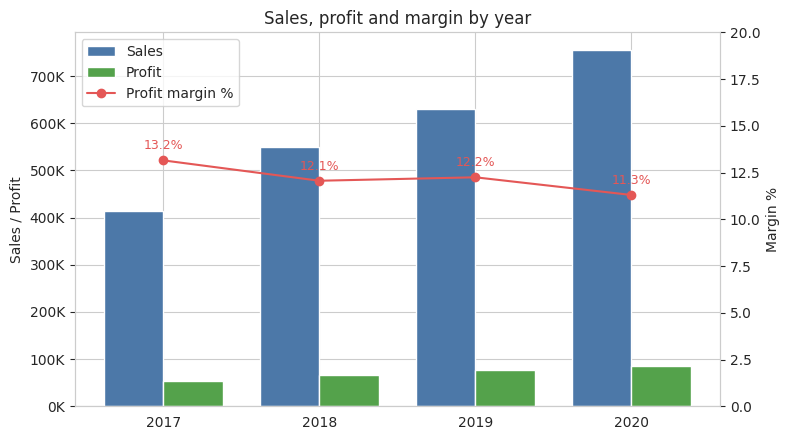

,Sales,Profit,Qty,Margin,Growth
Year,,,,,
2017,414493,54514,5494,0.131520,NaN
2018,548698,66186,7086,0.120624,0.323781
2019,630140,77172,7935,0.122468,0.148428
2020,755030,85330,9833,0.113015,0.198194


In [4]:
yr=df.groupby('Year').agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Qty=('Quantity','sum')); yr['Margin']=yr.Profit/yr.Sales; yr['Growth']=yr.Sales.pct_change()
cagr=(yr.Sales.iloc[-1]/yr.Sales.iloc[0])**(1/3)-1
RES['year']=yr.reset_index().replace({np.nan: None}).to_dict('records'); RES['cagr']=float(cagr)
fig,ax=plt.subplots(figsize=(8,4.5)); w=0.38; x=np.arange(len(yr))
ax.bar(x-w/2,yr.Sales,w,color=BLUE,label='Sales'); ax.bar(x+w/2,yr.Profit,w,color=GREEN,label='Profit')
ax.set_xticks(x); ax.set_xticklabels(yr.index); ax.yaxis.set_major_formatter(fmtK); ax.set_ylabel('Sales / Profit')
ax2=ax.twinx(); ax2.plot(x,yr.Margin*100,color=RED,marker='o',label='Profit margin %'); ax2.set_ylim(0,20); ax2.set_ylabel('Margin %'); ax2.grid(False)
for i,v in enumerate(yr.Margin*100): ax2.annotate(f'{v:.1f}%',(i,v),textcoords='offset points',xytext=(0,8),ha='center',color=RED,fontsize=9)
h1,l1=ax.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels(); ax.legend(h1+h2,l1+l2,loc='upper left'); ax.set_title('Sales, profit and margin by year')
plt.tight_layout(); plt.savefig(FIG+'01_year_trend.png',dpi=150); plt.show(); yr

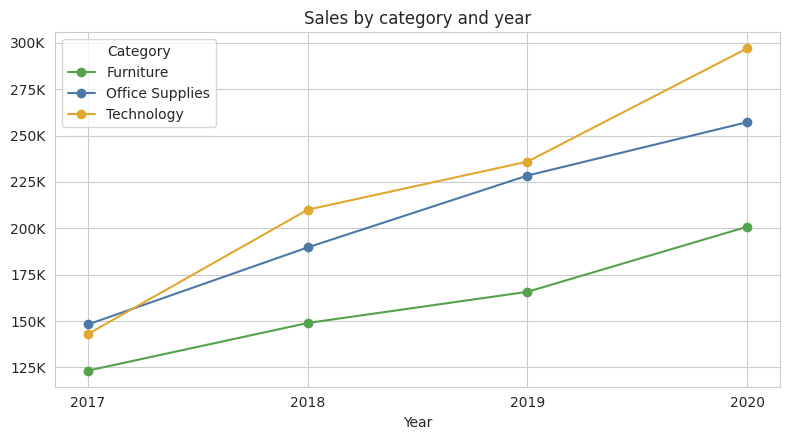

Category,Furniture,Office Supplies,Technology
Year,,,
2017,123273,148179,143041
2018,148956,189708,210034
2019,165757,228432,235951
2020,200823,257218,296989


In [5]:
cy=df.pivot_table(index='Year',columns='Category',values='Sales',aggfunc='sum')
RES['cat_year']=cy.reset_index().to_dict('records')
RES['cat_cagr']={c: float((cy[c].iloc[-1]/cy[c].iloc[0])**(1/3)-1) for c in cy}
ax=cy.plot(marker='o',figsize=(8,4.5),color=[GREEN,BLUE,GOLD]); ax.yaxis.set_major_formatter(fmtK); ax.set_title('Sales by category and year'); ax.set_xticks(cy.index)
plt.tight_layout(); plt.savefig(FIG+'02_category_year.png',dpi=150); plt.show(); cy

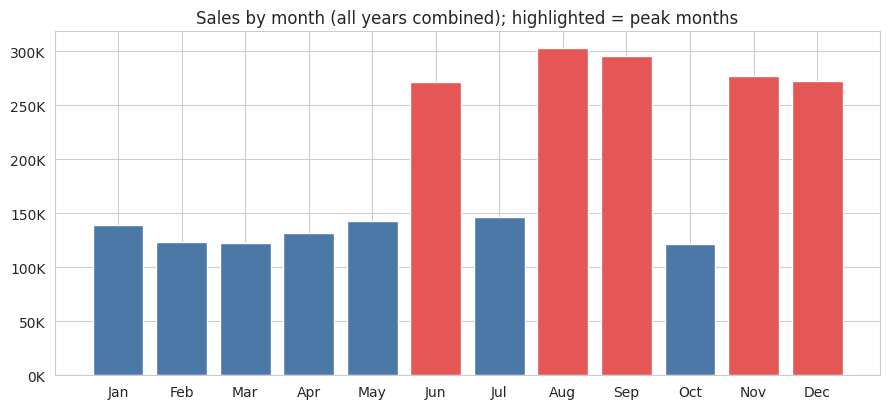

,Sales,Lines,Profit
Month,,,
1,139157,474,17507
2,123540,431,14455
3,122875,462,12930
4,132051,436,16004
5,142461,476,16171
6,271744,866,31769
7,146159,458,16694
8,303234,1134,38503
9,295289,969,37423


In [6]:
mo=df.groupby('Month').agg(Sales=('Sales','sum'),Lines=('Sales','size'),Profit=('Profit','sum'))
RES['month']=mo.reset_index().to_dict('records')
names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig,ax=plt.subplots(figsize=(9,4.2)); ax.bar(names,mo.Sales,color=[RED if m in (6,8,9,11,12) else BLUE for m in mo.index])
ax.yaxis.set_major_formatter(fmtK); ax.set_title('Sales by month (all years combined); highlighted = peak months'); plt.tight_layout(); plt.savefig(FIG+'03_monthly_sales.png',dpi=150); plt.show(); mo

## 4. Category and sub-category

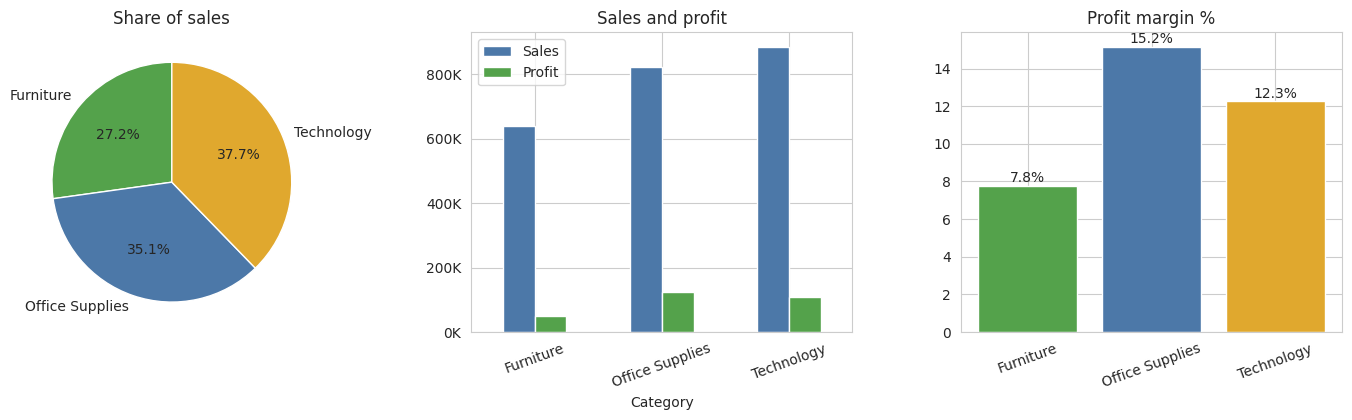

,Sales,Profit,Qty,Disc,Margin,Share
Category,,,,,,
Furniture,638809,49734,4641,0.155008,0.077854,0.272023
Office Supplies,823537,124914,19896,0.095004,0.151680,0.350686
Technology,886015,108554,5811,0.125837,0.122519,0.377291


In [7]:
cat=df.groupby('Category').agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Qty=('Quantity','sum'),Disc=('Discount','mean')); cat['Margin']=cat.Profit/cat.Sales; cat['Share']=cat.Sales/cat.Sales.sum()
RES['cat']=cat.reset_index().to_dict('records')
fig,ax=plt.subplots(1,3,figsize=(14,4.3))
ax[0].pie(cat.Sales,labels=cat.index,autopct='%1.1f%%',colors=[GREEN,BLUE,GOLD],startangle=90); ax[0].set_title('Share of sales')
cat[['Sales','Profit']].plot.bar(ax=ax[1],color=[BLUE,GREEN]); ax[1].yaxis.set_major_formatter(fmtK); ax[1].set_title('Sales and profit'); ax[1].tick_params(axis='x',rotation=20)
ax[2].bar(cat.index,cat.Margin*100,color=[GREEN,BLUE,GOLD]); ax[2].set_title('Profit margin %'); ax[2].tick_params(axis='x',rotation=20)
for i,v in enumerate(cat.Margin*100): ax[2].text(i,v+.2,f'{v:.1f}%',ha='center')
plt.tight_layout(); plt.savefig(FIG+'04_category.png',dpi=150); plt.show(); cat

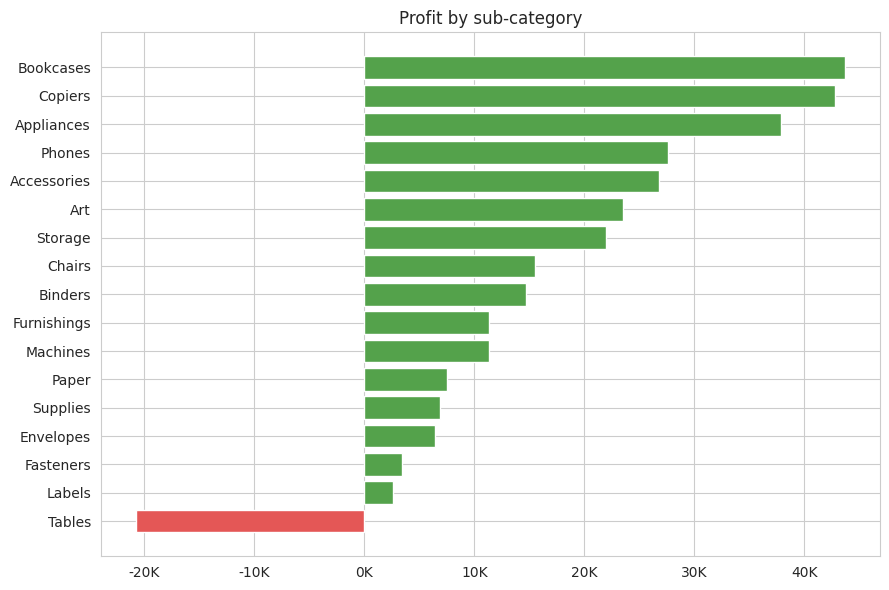

,Category,Sub-Category,Sales,Profit,Disc,Margin
3,Furniture,Tables,89478,-20731,0.369333,-0.231688
9,Office Supplies,Labels,12822,2636,0.066667,0.205584
8,Office Supplies,Fasteners,16238,3420,0.103429,0.210617
7,Office Supplies,Envelopes,31210,6463,0.071676,0.207081
12,Office Supplies,Supplies,38824,6853,0.063977,0.176515
10,Office Supplies,Paper,36057,7485,0.071390,0.207588
15,Technology,Machines,182066,11318,0.155821,0.062164
2,Furniture,Furnishings,68237,11321,0.105141,0.165907
6,Office Supplies,Binders,78850,14675,0.070416,0.186113
1,Furniture,Chairs,186698,15489,0.203394,0.082963


In [8]:
sub=df.groupby(['Category','Sub-Category']).agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Disc=('Discount','mean')).reset_index(); sub['Margin']=sub.Profit/sub.Sales
RES['sub']=sub.sort_values('Profit').to_dict('records')
s=sub.sort_values('Profit'); fig,ax=plt.subplots(figsize=(9,6)); ax.barh(s['Sub-Category'],s.Profit,color=[RED if v<0 else GREEN for v in s.Profit])
ax.xaxis.set_major_formatter(fmtK); ax.set_title('Profit by sub-category'); plt.tight_layout(); plt.savefig(FIG+'05_subcategory_profit.png',dpi=150); plt.show(); s

## 5. Geography

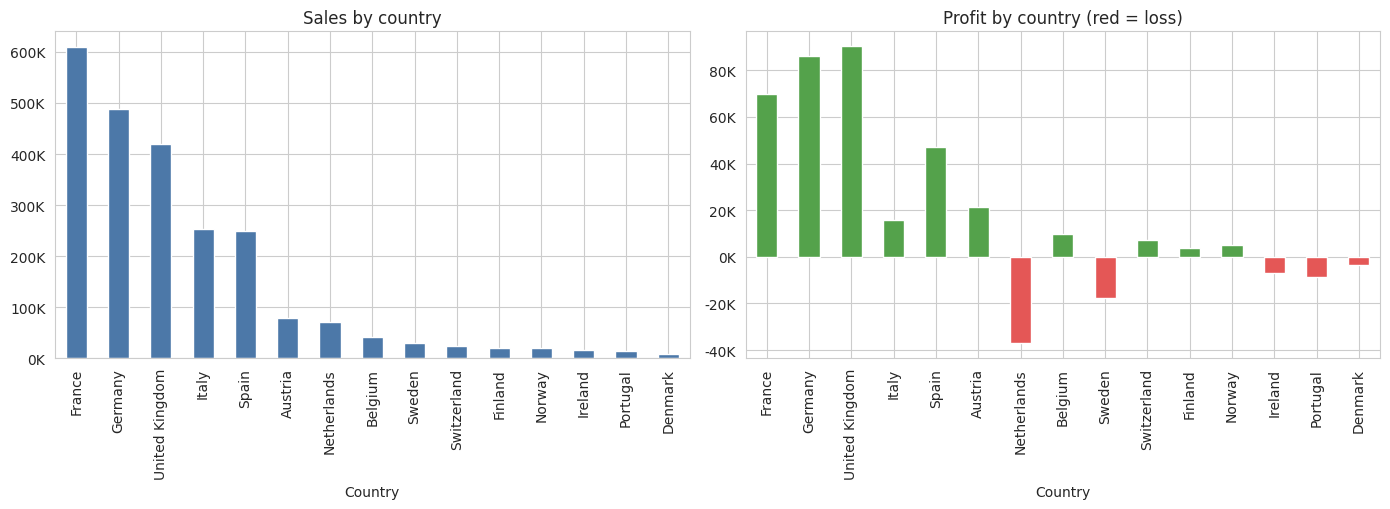

,Sales,Profit,Disc,Lines,Margin
Country,,,,,
France,609683,70067,0.076722,1916,0.114924
Germany,488764,86291,0.054753,1641,0.176549
United Kingdom,420414,90370,0.070221,1313,0.214955
Italy,252742,15802,0.125230,979,0.062522
Spain,249318,47039,0.034342,760,0.188671
Austria,79382,21332,0.000000,264,0.268726
Netherlands,70313,-37188,0.480662,393,-0.528892
Belgium,42283,9902,0.000000,134,0.234184
Sweden,30490,-17524,0.507882,203,-0.574746


In [9]:
co=df.groupby('Country').agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Disc=('Discount','mean'),Lines=('Sales','size')).sort_values('Sales',ascending=False); co['Margin']=co.Profit/co.Sales
RES['country']=co.reset_index().to_dict('records')
fig,ax=plt.subplots(1,2,figsize=(14,5.2)); co.Sales.plot.bar(ax=ax[0],color=BLUE); ax[0].yaxis.set_major_formatter(fmtK); ax[0].set_title('Sales by country')
co.Profit.plot.bar(ax=ax[1],color=[RED if v<0 else GREEN for v in co.Profit]); ax[1].yaxis.set_major_formatter(fmtK); ax[1].set_title('Profit by country (red = loss)')
plt.tight_layout(); plt.savefig(FIG+'06_country.png',dpi=150); plt.show(); co

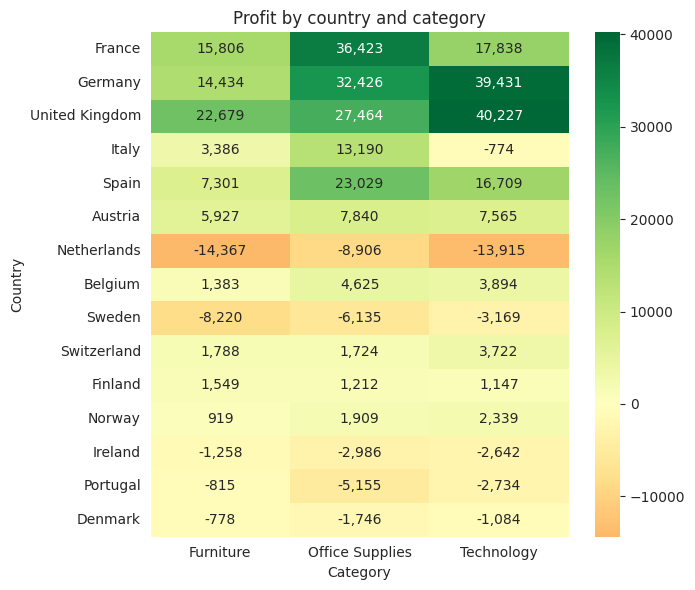

In [10]:
hm=df.pivot_table(index='Country',columns='Category',values='Profit',aggfunc='sum').loc[co.index]
RES['country_cat_profit']=hm.reset_index().to_dict('records')
plt.figure(figsize=(7,6)); sns.heatmap(hm,annot=True,fmt=',.0f',cmap='RdYlGn',center=0); plt.title('Profit by country and category'); plt.tight_layout(); plt.savefig(FIG+'07_country_category_heatmap.png',dpi=150); plt.show()

orders shipped before order date: 24 [-365, 8]
              min  max  mean
Ship Mode                   
Economy      -362    8  2.32
Economy Plus -364    6  2.35
Immediate       0    1  0.05
Priority     -365    3 -0.15


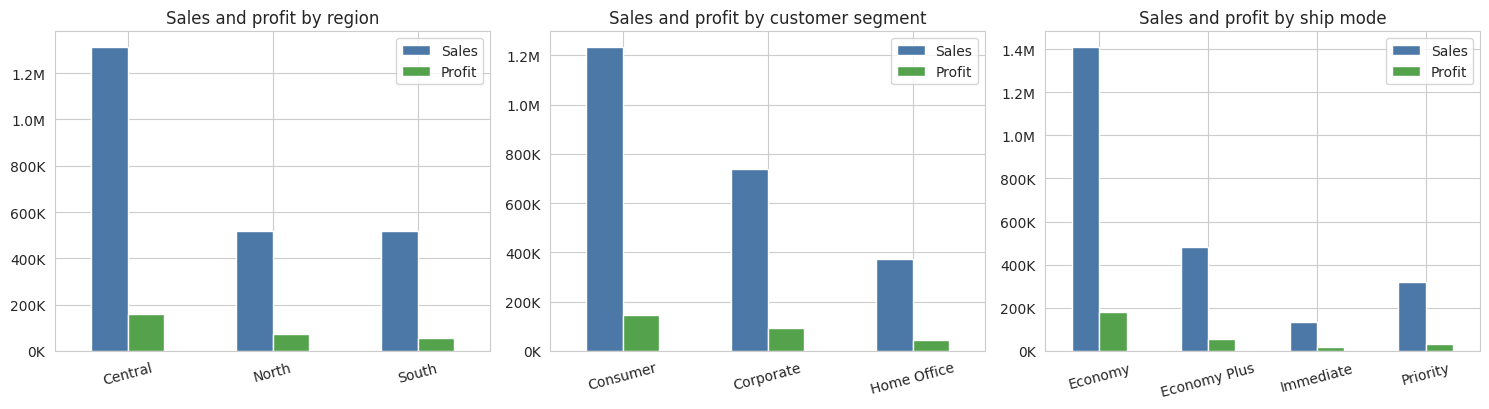

(           Sales  Profit    Margin
 Region                            
 Central  1315299  157638  0.119850
 North     515896   71427  0.138452
 South     517166   54137  0.104680,
                Sales  Profit    Margin
 Segment                               
 Consumer     1236245  147437  0.119262
 Corporate     738199   92649  0.125507
 Home Office   373917   43116  0.115309,
                 Sales  Profit    Margin
 Ship Mode                              
 Economy       1412511  178631  0.126463
 Economy Plus   483965   54336  0.112273
 Immediate      131459   17596  0.133852
 Priority       320426   32639  0.101861)

In [11]:
reg=df.groupby('Region')[['Sales','Profit']].sum(); seg=df.groupby('Segment')[['Sales','Profit']].sum(); shp=df.groupby('Ship Mode')[['Sales','Profit']].sum()
for t in (reg,seg,shp): t['Margin']=t.Profit/t.Sales
RES['region']=reg.reset_index().to_dict('records'); RES['segment']=seg.reset_index().to_dict('records'); RES['ship']=shp.reset_index().to_dict('records')
RES['ship_days']=df.groupby('Ship Mode')['Ship Days'].mean().round(2).to_dict()
od=orders.assign(d=(orders['Ship Date']-orders['Order Date']).dt.days)
RES['ship_neg_orders']=int((od.d<0).sum()); RES['ship_neg_share']=float((od.d<0).mean()); RES['ship_days_range']=[int(od.d.min()),int(od.d.max())]
print('orders shipped before order date:',RES['ship_neg_orders'],RES['ship_days_range'])
print(od.groupby('Ship Mode').d.agg(['min','max','mean']).round(2))
fig,ax=plt.subplots(1,3,figsize=(15,4.2))
for a,t,ttl in zip(ax,(reg,seg,shp),('Region','Customer segment','Ship mode')):
    t[['Sales','Profit']].plot.bar(ax=a,color=[BLUE,GREEN]); a.yaxis.set_major_formatter(fmtK); a.set_title(f'Sales and profit by {ttl.lower()}'); a.tick_params(axis='x',rotation=15); a.set_xlabel('')
plt.tight_layout(); plt.savefig(FIG+'08_region_segment_ship.png',dpi=150); plt.show(); reg,seg,shp

## 6. Products

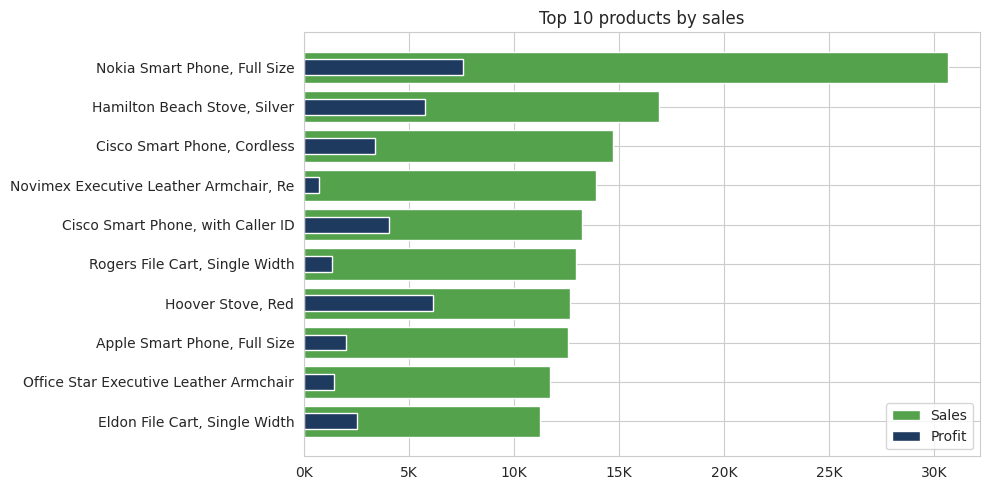

,Sales,Profit,Qty
Product Name,,,
"Nokia Smart Phone, Full Size",30645,7583,54
"Hamilton Beach Stove, Silver",16890,5778,33
"Cisco Smart Phone, Cordless",14723,3388,29
"Novimex Executive Leather Armchair, Red",13898,736,44
"Cisco Smart Phone, with Caller ID",13215,4055,25
"Rogers File Cart, Single Width",12967,1312,108
"Hoover Stove, Red",12677,6139,23
"Apple Smart Phone, Full Size",12555,2001,23
"Office Star Executive Leather Armchair, Adjustable",11687,1440,30


In [12]:
pr=df.groupby('Product Name').agg(Sales=('Sales','sum'),Profit=('Profit','sum'),Qty=('Quantity','sum')).sort_values('Sales',ascending=False)
top=pr.head(10); RES['top_products']=top.reset_index().to_dict('records')
RES['product_loss']=pr.sort_values('Profit').head(5).reset_index().to_dict('records')
RES['top10_share']=float(top.Sales.sum()/pr.Sales.sum())
fig,ax=plt.subplots(figsize=(10,5)); t=top.iloc[::-1]; ax.barh([n[:38] for n in t.index],t.Sales,color=GREEN,label='Sales'); ax.barh([n[:38] for n in t.index],t.Profit,color=NAVY,height=.4,label='Profit')
ax.xaxis.set_major_formatter(fmtK); ax.legend(); ax.set_title('Top 10 products by sales'); plt.tight_layout(); plt.savefig(FIG+'09_top_products.png',dpi=150); plt.show(); top

## 7. Discount and returns

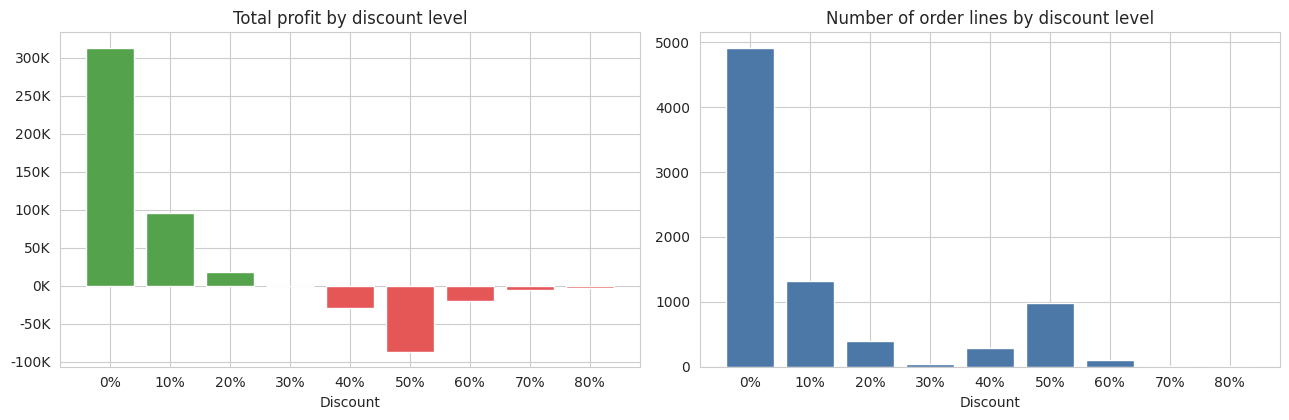

,Lines,Sales,Profit,Margin
DiscBand,,,,
No discount,4907,1232747,313131,0.254011
10-20%,1712,801363,113923,0.142162
30-40%,322,115932,-28233,-0.243531
50-80%,1104,198319,-115619,-0.582995


In [13]:
df['DiscBand']=pd.cut(df.Discount,[-0.01,0,0.2,0.4,1],labels=['No discount','10-20%','30-40%','50-80%'])
db=df.groupby('DiscBand').agg(Lines=('Sales','size'),Sales=('Sales','sum'),Profit=('Profit','sum')); db['Margin']=db.Profit/db.Sales
RES['disc_band']=db.reset_index().astype({'DiscBand':str}).to_dict('records')
dd=df.groupby(df.Discount.round(1)).agg(Lines=('Sales','size'),Sales=('Sales','sum'),Profit=('Profit','sum'))
RES['disc_level']=dd.reset_index().to_dict('records')
RES['disc_ge30']={'lines':int((df.Discount>=0.3).sum()),'share_lines':float((df.Discount>=0.3).mean()),'profit':int(df.loc[df.Discount>=0.3,'Profit'].sum()),'sales':int(df.loc[df.Discount>=0.3,'Sales'].sum())}
fig,ax=plt.subplots(1,2,figsize=(13,4.3)); ax[0].bar([f'{int(i*100)}%' for i in dd.index],dd.Profit,color=[RED if v<0 else GREEN for v in dd.Profit]); ax[0].yaxis.set_major_formatter(fmtK); ax[0].set_title('Total profit by discount level'); ax[0].set_xlabel('Discount')
ax[1].bar([f'{int(i*100)}%' for i in dd.index],dd.Lines,color=BLUE); ax[1].set_title('Number of order lines by discount level'); ax[1].set_xlabel('Discount')
plt.tight_layout(); plt.savefig(FIG+'10_discount.png',dpi=150); plt.show(); db

In [14]:
cd=df.groupby('Country').agg(avg_disc=('Discount','mean'),high=('Discount',lambda s:(s>=0.3).mean())); RES['country_disc']=cd.round(3).reset_index().to_dict('records')
tb=df[df['Sub-Category']=='Tables']; RES['tables']={'avg_disc':float(tb.Discount.mean()),'share_high':float((tb.Discount>=0.3).mean()),'profit_ge30':int(tb.loc[tb.Discount>=0.3,'Profit'].sum()),'profit_lt30':int(tb.loc[tb.Discount<0.3,'Profit'].sum())}
nl=df[df.Country=='Netherlands']; RES['nl']={'avg_disc':float(nl.Discount.mean()),'share_high':float((nl.Discount>=0.3).mean()),'profit_ge30':int(nl.loc[nl.Discount>=0.3,'Profit'].sum()),'profit_lt30':int(nl.loc[nl.Discount<0.3,'Profit'].sum())}
RES['all_disc_avg']=float(df.Discount.mean()); RES['all_high_share']=float((df.Discount>=0.3).mean())
print(RES['tables'],RES['nl'],RES['all_disc_avg'],RES['all_high_share']); cd.round(3)

{'avg_disc': 0.36933333333333335, 'share_high': 0.8266666666666667, 'profit_ge30': -25384, 'profit_lt30': 4653} {'avg_disc': 0.48066157760814243, 'share_high': 0.9287531806615776, 'profit_ge30': -37377, 'profit_lt30': 189} 0.11007458048477316 0.17725295214418893


,avg_disc,high
Country,,
Austria,0.000,0.000
Belgium,0.000,0.000
Denmark,0.508,1.000
Finland,0.000,0.000
France,0.077,0.060
Germany,0.055,0.040
Ireland,0.503,1.000
Italy,0.125,0.291
Netherlands,0.481,0.929


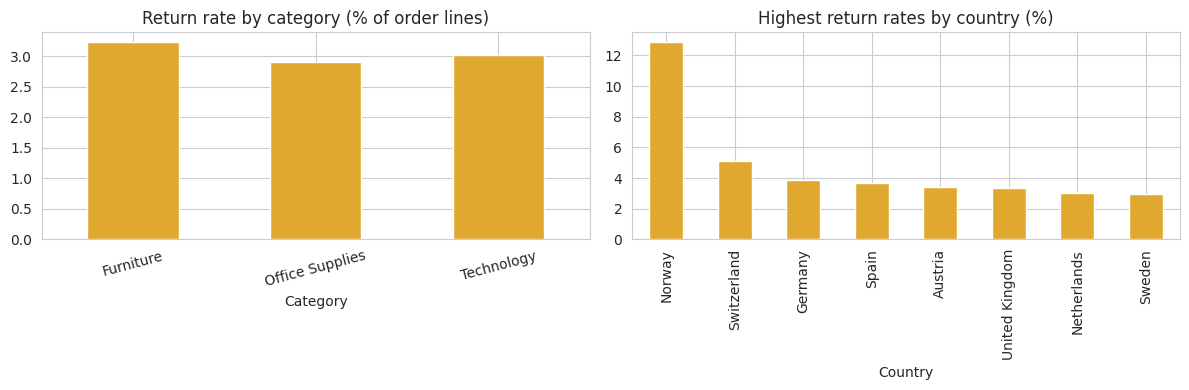

,Lines,Sales,Profit
Return Status,,,
Returned,240,82942,12511
Sold,7805,2265419,270691


In [15]:
rt=df.groupby('Return Status').agg(Lines=('Sales','size'),Sales=('Sales','sum'),Profit=('Profit','sum')); RES['returns']=rt.reset_index().to_dict('records')
rc=df.groupby('Category')['Return Status'].apply(lambda s:(s=='Returned').mean()); RES['return_rate_cat']=rc.to_dict(); RES['return_rate']=float((df['Return Status']=='Returned').mean())
rcn=df.groupby('Country')['Return Status'].apply(lambda s:(s=='Returned').mean()).sort_values(ascending=False); RES['return_rate_country']=rcn.round(4).to_dict()
fig,ax=plt.subplots(1,2,figsize=(12,4)); (rc*100).plot.bar(ax=ax[0],color=GOLD); ax[0].set_title('Return rate by category (% of order lines)'); ax[0].tick_params(axis='x',rotation=15)
(rcn.head(8)*100).plot.bar(ax=ax[1],color=GOLD); ax[1].set_title('Highest return rates by country (%)')
plt.tight_layout(); plt.savefig(FIG+'11_returns.png',dpi=150); plt.show(); rt

In [16]:
RES['corr']={'disc_profit_margin': float(df.assign(m=df.Profit/df.Sales)[['Discount','m']].corr().iloc[0,1]),'sales_qty':float(df[['Sales','Quantity']].corr().iloc[0,1])}
json.dump(RES,open('../report/results.json','w'),default=lambda o:(int(o) if isinstance(o,np.integer) else float(o) if isinstance(o,np.floating) else str(o)),indent=1)
print('saved', RES['corr'])

saved {'disc_profit_margin': -0.8199941611653985, 'sales_qty': 0.353415365258626}
